# Predicting UMKM Success Using Machine Learning

---

## Project Overview

This project develops machine learning models to predict the success of Micro, Small, and Medium Enterprises (UMKM). In addition to building predictive models, the analysis identifies the key factors influencing business success and provides data-driven recommendations for stakeholders.

## 1. Import Libraries



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading

In [ ]:
from pathlib import Path

DATA_PATH = Path("data") / "umkm.csv"

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print('\n--- 5 Baris Pertama ---')
display(df.head())
print('\n--- Info Dataset ---')
df.info()
print('\n--- Statistik Deskriptif ---')
display(df.describe())


Shape: (250, 13)

--- 5 Baris Pertama ---


,Age,Education,Initial_Capital,Financial_Record_Keeping,Internet_Usage,Business_Plan,Marketing_Effort,Partnership,Parent_Business_Experience,Industry_Experience,Owner_Gender,Professional_Advice,Success
0,60,3,0,0,0,0,5,1,1,5,1,3,0
1,51,4,1,1,0,0,7,1,1,4,1,7,0
2,21,1,0,1,1,0,7,0,0,19,1,2,0
3,20,1,0,1,1,1,5,1,0,1,1,2,0
4,35,1,1,1,0,1,3,0,1,3,0,1,0



--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         250 non-null    int64
 1   Education                   250 non-null    int64
 2   Initial_Capital             250 non-null    int64
 3   Financial_Record_Keeping    250 non-null    int64
 4   Internet_Usage              250 non-null    int64
 5   Business_Plan               250 non-null    int64
 6   Marketing_Effort            250 non-null    int64
 7   Partnership                 250 non-null    int64
 8   Parent_Business_Experience  250 non-null    int64
 9   Industry_Experience         250 non-null    int64
 10  Owner_Gender                250 non-null    int64
 11  Professional_Advice         250 non-null    int64
 12  Success                     250 non-null    int64
dtypes: int64(13)
memory usage: 25.5 KB

--- Sta

,Age,Education,Initial_Capital,Financial_Record_Keeping,Internet_Usage,Business_Plan,Marketing_Effort,Partnership,Parent_Business_Experience,Industry_Experience,Owner_Gender,Professional_Advice,Success
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,39.760000,2.876000,0.516000,0.488000,0.440000,0.524000,3.996000,0.460000,0.440000,9.760000,0.564000,4.140000,0.248000
std,12.805559,1.407319,0.500746,0.500859,0.497383,0.500426,1.992955,0.499397,0.497383,6.164935,0.496882,2.078867,0.432718
min,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,29.000000,2.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,5.000000,0.000000,2.000000,0.000000
50%,40.000000,3.000000,1.000000,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,10.000000,1.000000,4.000000,0.000000
75%,51.000000,4.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,15.000000,1.000000,6.000000,0.000000
max,60.000000,5.000000,1.000000,1.000000,1.000000,1.000000,7.000000,1.000000,1.000000,20.000000,1.000000,7.000000,1.000000


## 3. Exploratory Data Analysis


--- Missing Values ---
Tidak ada missing values

--- Duplicate Values ---
Tidak ada duplicated values


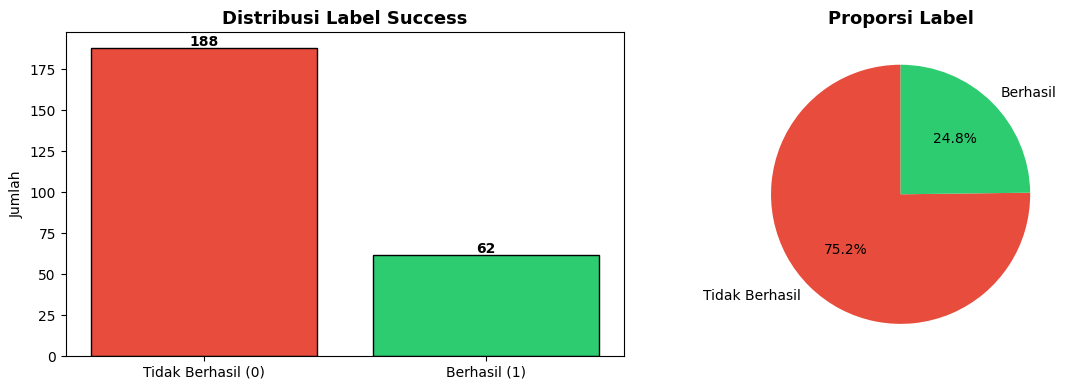

Rasio imbalance (0:1) = 3.03
⚠️ Perlu SMOTE!


In [ ]:
# Missing Values
print('\n--- Missing Values ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values')

# Duplicate Values
print('\n--- Duplicate Values ---')
dupe = df.duplicated().sum()
print(dupe[dupe > 0] if dupe.sum() > 0 else 'Tidak ada duplicated values')

# Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts = df['Success'].value_counts()
axes[0].bar(['Tidak Berhasil (0)', 'Berhasil (1)'], target_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Label Success', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
target_counts.plot.pie(ax=axes[1], autopct='%1.1f%%',
                       labels=['Tidak Berhasil', 'Berhasil'],
                       colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporsi Label', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = target_counts[0] / target_counts[1]
print(f'Rasio imbalance (0:1) = {imbalance_ratio:.2f}')
print('⚠️ Perlu SMOTE!' if imbalance_ratio > 1.5 or imbalance_ratio < 0.67 else '✅ Data cukup seimbang')


## 4. Feature Engineering

In [ ]:
df_eng = df.copy()

df_eng['Digital_Readiness'] = (
    df_eng['Internet_Usage'] +
    df_eng['Business_Plan'] +
    (df_eng['Professional_Advice'] >= 4).astype(int)
)

df_eng['Financial_Health'] = (
    df_eng['Initial_Capital'] + df_eng['Financial_Record_Keeping']
)

df_eng['Experience_Score'] = (
    df_eng['Industry_Experience'] / df_eng['Industry_Experience'].max() +
    df_eng['Parent_Business_Experience']
)

df_eng['Marketing_Digital'] = (
    df_eng['Marketing_Effort'] * df_eng['Internet_Usage']
)

selected_features = [
    'Initial_Capital', 'Financial_Record_Keeping',
    'Internet_Usage', 'Business_Plan',
    'Industry_Experience', 'Professional_Advice',
    'Digital_Readiness', 'Financial_Health',
    'Experience_Score', 'Marketing_Digital'
]

X = df_eng[selected_features]
y = df_eng['Success']

print(f'Shape X: {X.shape}')
print(f'Features: {selected_features}')


Shape X: (250, 10)
Features: ['Initial_Capital', 'Financial_Record_Keeping', 'Internet_Usage', 'Business_Plan', 'Industry_Experience', 'Professional_Advice', 'Digital_Readiness', 'Financial_Health', 'Experience_Score', 'Marketing_Digital']


## 5. Train-Test Split



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


print(f'Train Size: {dict(y_train.value_counts())}')
print(f'Test size: {X_test.shape[0]} samples')


Train Size: {0: 132, 1: 43}
Test size: 75 samples


## 6. Model Development

Running CV: Logistic Regression...
  AUC-ROC: 0.9939 ± 0.0082
Running CV: XGBoost...
  AUC-ROC: 0.9842 ± 0.0149
Running CV: TabICL...
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]

  AUC-ROC: 0.9914 ± 0.0103

--- Hasil Repeated CV (5-fold × 10 repeat) ---


,F1,AUC-ROC,Precision,Recall
Logistic Regression,0.9444 ± 0.0439,0.9939 ± 0.0082,0.9545 ± 0.0329,0.9423 ± 0.0462
XGBoost,0.9341 ± 0.0414,0.9842 ± 0.0149,0.9381 ± 0.0385,0.9354 ± 0.0403
TabICL,0.9503 ± 0.0348,0.9914 ± 0.0103,0.9546 ± 0.0321,0.9503 ± 0.0351


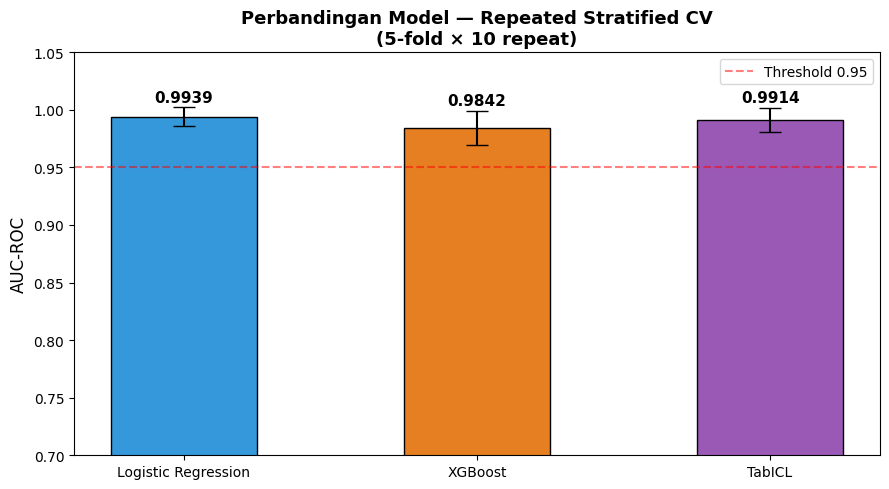

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from tabicl import TabICLClassifier

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

scoring = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1_weighted',
    'precision': 'precision_weighted',
    'recall'   : 'recall_weighted'
}

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8,
        eval_metric='logloss', random_state=42
    ),
    'TabICL': TabICLClassifier(
        n_estimators=128,
        n_jobs=1,
        random_state=42
    ),
}

summary = {}

for name, model in models.items():
    print(f'Running CV: {name}...')
    jobs = 1 if name == 'TabICL' else -1
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=rskf, scoring=scoring, n_jobs=jobs
    )
    summary[name] = {
        'F1'       : f"{cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}",
        'AUC-ROC'  : f"{cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}",
        'Precision': f"{cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}",
        'Recall'   : f"{cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}",
        '_auc_mean': cv_results['test_roc_auc'].mean(),
        '_auc_std' : cv_results['test_roc_auc'].std(),
    }
    print(f"  AUC-ROC: {summary[name]['AUC-ROC']}")

display_df = pd.DataFrame(summary).T[['F1','AUC-ROC','Precision','Recall']]
print('\n--- Hasil Repeated CV (5-fold × 10 repeat) ---')
display(display_df)

# Visualisasi
names  = list(summary.keys())
means  = [summary[n]['_auc_mean'] for n in names]
stds   = [summary[n]['_auc_std']  for n in names]
colors = ['#3498db', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, means, yerr=stds, capsize=8,
              color=colors, edgecolor='black', width=0.5)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Perbandingan Model — Repeated Stratified CV\n(5-fold × 10 repeat)',
             fontsize=13, fontweight='bold')
ax.axhline(0.95, color='red', linestyle='--', alpha=0.5, label='Threshold 0.95')
ax.legend()
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            mean + std + 0.005,
            f'{mean:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Evaluation

Model terbaik: Logistic Regression

--- Evaluasi Test Set ---
Accuracy : 0.8933
F1-Score : 0.8964
AUC-ROC  : 0.9709
                precision    recall  f1-score   support

Tidak Berhasil       0.96      0.89      0.93        56
      Berhasil       0.74      0.89      0.81        19

      accuracy                           0.89        75
     macro avg       0.85      0.89      0.87        75
  weighted avg       0.91      0.89      0.90        75



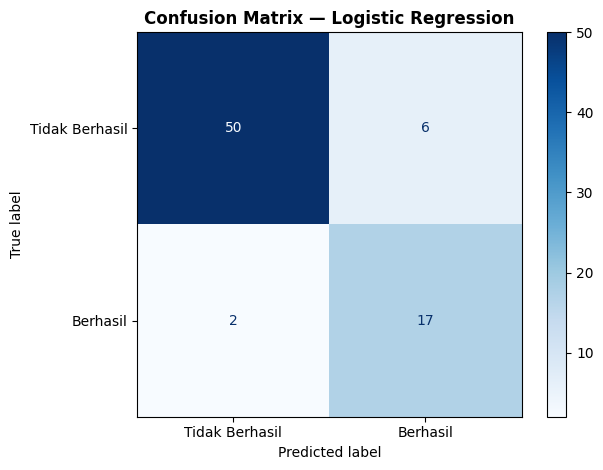

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)


best_model_name = max(summary, key=lambda n: summary[n]['_auc_mean'])
print(f'Model terbaik: {best_model_name}')

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print('\n--- Evaluasi Test Set ---')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}')
print(classification_report(y_test, y_pred, target_names=['Tidak Berhasil', 'Berhasil']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Tidak Berhasil', 'Berhasil'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Model: TabICL

--- Evaluasi Test Set ---
Accuracy : 0.9067
F1-Score : 0.9058
AUC-ROC  : 0.9765
                precision    recall  f1-score   support

Tidak Berhasil       0.93      0.95      0.94        56
      Berhasil       0.83      0.79      0.81        19

      accuracy                           0.91        75
     macro avg       0.88      0.87      0.87        75
  weighted avg       0.91      0.91      0.91        75



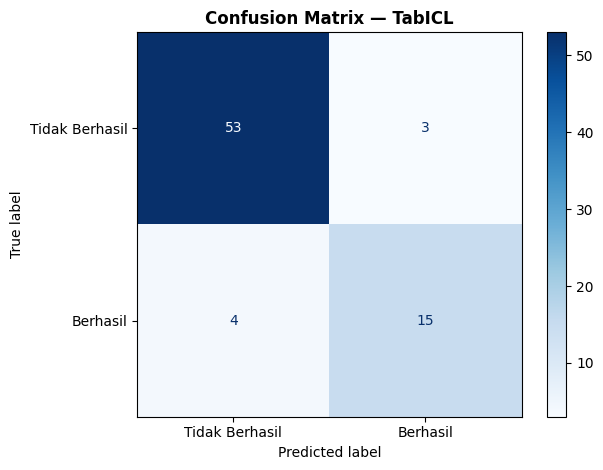

In [ ]:

model_name = 'TabICL'
model_name = models[model_name]


model_name.fit(X_train, y_train)

y_pred = model_name.predict(X_test)
y_prob = model_name.predict_proba(X_test)[:, 1]

print(f'Model: {model_name}')
print('\n--- Evaluasi Test Set ---')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}')
print(classification_report(y_test, y_pred, target_names=['Tidak Berhasil', 'Berhasil']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Tidak Berhasil', 'Berhasil'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance Analysis

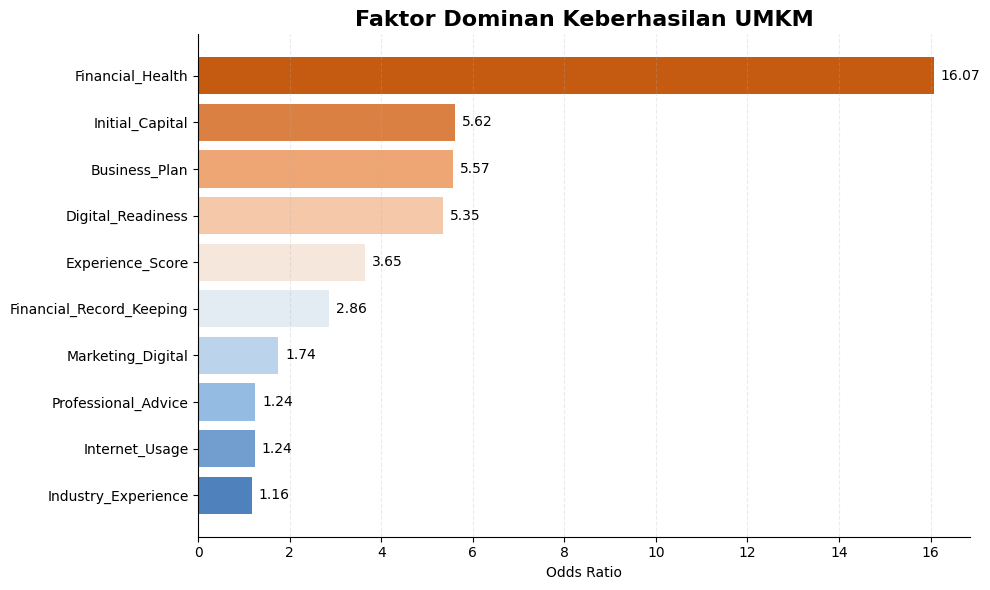

In [ ]:
from matplotlib.colors import LinearSegmentedColormap



logistic_model = models['Logistic Regression']
logistic_model.fit(X_train, y_train)


features = X_train.columns

coefficients = logistic_model.coef_[0]


odds_ratios = np.exp(coefficients)


coef_df = pd.DataFrame({
    "Feature": features,
    "Odds_Ratio": odds_ratios
})

or_plot = coef_df.sort_values(
    "Odds_Ratio",
    ascending=False
)


cmap = LinearSegmentedColormap.from_list(
    "blue_orange",
    [
        "#4F81BD",
        "#9DC3E6",
        "#F7F7F7",
        "#F4B183",
        "#C55A11"
    ]
)

colors = cmap(
    np.linspace(1, 0, len(or_plot))
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    or_plot["Feature"],
    or_plot["Odds_Ratio"],
    color=colors,
    edgecolor='none'
)

plt.gca().invert_yaxis()

plt.title(
    "Faktor Dominan Keberhasilan UMKM",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Odds Ratio")
plt.ylabel("")

plt.grid(
    axis='x',
    alpha=0.25,
    linestyle='--'
)

for i, v in enumerate(or_plot["Odds_Ratio"]):
    plt.text(
        v + 0.15,
        i,
        f"{v:.2f}",
        va='center',
        fontsize=10
    )

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Success Rate by Key Features

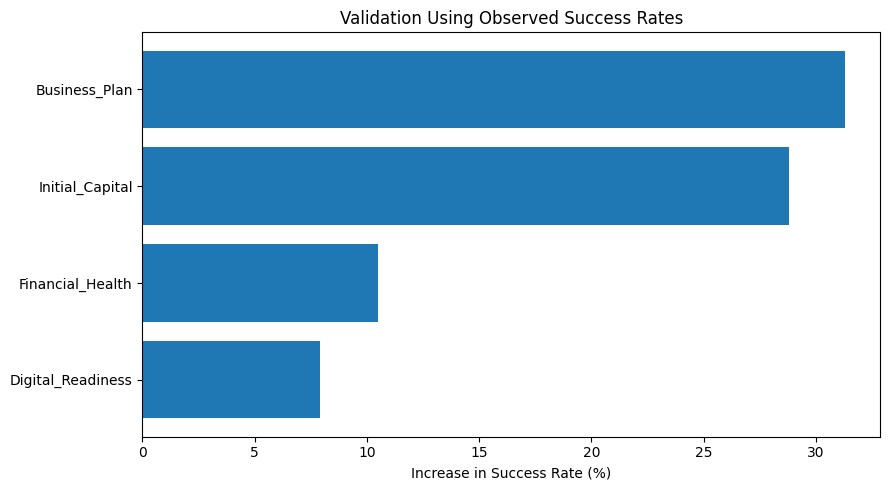

In [ ]:
top_features = [
    "Financial_Health",
    "Initial_Capital",
    "Business_Plan",
    "Digital_Readiness"
]
validation_results = []

for feature in top_features:

    success_without = (
        df_eng[df_eng[feature] == 0]["Success"]
        .mean() * 100
    )

    success_with = (
        df_eng[df_eng[feature] == 1]["Success"]
        .mean() * 100
    )

    validation_results.append({
        "Feature": feature,
        "Without": round(success_without, 1),
        "With": round(success_with, 1),
        "Improvement": round(
            success_with - success_without,
            1
        )
    })

validation_df = pd.DataFrame(
    validation_results
)

validation_df.sort_values(
    "Improvement",
    ascending=False,
    inplace=True
)

plot_df = validation_df.sort_values(
    "Improvement",
    ascending=False
)

plt.figure(figsize=(9,5))

plt.barh(
    plot_df["Feature"],
    plot_df["Improvement"]
)

plt.gca().invert_yaxis()

plt.xlabel(
    "Increase in Success Rate (%)"
)

plt.title(
    "Validation Using Observed Success Rates"
)

plt.tight_layout()
plt.show()

## 10. High-Potential UMKM Profile

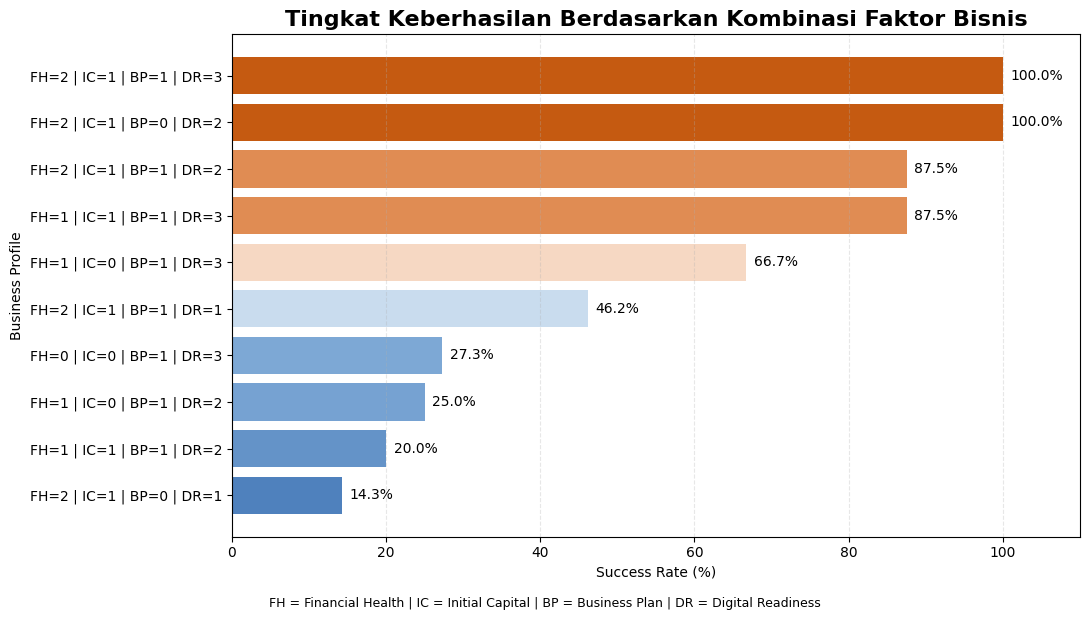

In [ ]:
from matplotlib.colors import Normalize

important = [
    "Financial_Health",
    "Initial_Capital",
    "Business_Plan",
    "Digital_Readiness"
]

profile_df = (
    df_eng.groupby(important)
    .agg(
        Count=("Success", "count"),
        Success_Rate=("Success", "mean")
    )
    .reset_index()
)

profile_df["Success_Rate"] *= 100


profile_df = profile_df[
    profile_df["Count"] >= 5
]

profile_df["Profile"] = (
    "FH=" + profile_df["Financial_Health"].astype(str)
    + " | IC=" + profile_df["Initial_Capital"].astype(str)
    + " | BP=" + profile_df["Business_Plan"].astype(str)
    + " | DR=" + profile_df["Digital_Readiness"].astype(str)
)
profile_df = profile_df.sort_values(
    "Success_Rate",
    ascending=False
)


profile_df = profile_df[
    profile_df["Success_Rate"] > 0
]


profile_df = profile_df.head(10)

cmap = LinearSegmentedColormap.from_list(
    "blue_orange",
    [
        "#4F81BD",
        "#9DC3E6",
        "#F7F7F7",
        "#F4B183",
        "#C55A11"
    ]
)

norm = Normalize(
    vmin=profile_df["Success_Rate"].min(),
    vmax=profile_df["Success_Rate"].max()
)

colors = cmap(norm(profile_df["Success_Rate"]))

plt.figure(figsize=(11, 6))

bars = plt.barh(
    profile_df["Profile"],
    profile_df["Success_Rate"],
    color=colors
)

plt.gca().invert_yaxis()


for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

plt.xlabel("Success Rate (%)")
plt.ylabel("Business Profile")

plt.title(
    "Tingkat Keberhasilan Berdasarkan Kombinasi Faktor Bisnis",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.xlim(0, 110)
plt.figtext(
    0.5,
    -0.02,
    "FH = Financial Health | IC = Initial Capital | BP = Business Plan | DR = Digital Readiness",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

## 11. Business Recommendations

In [ ]:
recommendation = pd.DataFrame({
    "Priority":[1,2,3,4],
    "Factor":[
        "Financial Health",
        "Initial Capital",
        "Business Plan",
        "Digital Readiness"
    ],
    "Odds Ratio":[
        16.07,
        5.62,
        5.57,
        5.35
    ]
})

recommendation

,Priority,Factor,Odds Ratio
0,1,Financial Health,16.07
1,2,Initial Capital,5.62
2,3,Business Plan,5.57
3,4,Digital Readiness,5.35


---

## 12. Conclusion

Berdasarkan hasil evaluasi, TabICL menghasilkan performa prediksi terbaik dengan F1-score sebesar 0.9503, sedangkan Logistic Regression dipilih sebagai model interpretasi karena memiliki AUC-ROC tertinggi dan memungkinkan analisis faktor dominan menggunakan odds ratio.

Analisis menunjukkan bahwa Financial Health, Initial Capital, Business Plan, dan Digital Readiness merupakan faktor yang paling berpengaruh terhadap keberhasilan UMKM. Kombinasi faktor-faktor tersebut membentuk profil UMKM dengan tingkat keberhasilan tertinggi dan menjadi dasar penyusunan rekomendasi strategis berbasis data.